In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import pearsonr

In [2]:
ratings = pd.read_csv('/Users/souravmb/Downloads/explicit_ratings_fr.csv')
items   = pd.read_csv('/Users/souravmb/Downloads/items_fr.csv')

In [4]:
ratings.head(7)

,user_id,item_id,watch_percentage,created_at,rating
0,468680,3,100,2020-01-09 10:48:06,10
1,468680,7,100,2020-03-23 10:41:36,10
2,468680,16,100,2020-03-23 14:17:37,10
3,468680,17,100,2020-03-31 14:33:58,10
4,468680,28,6,2020-03-23 10:34:15,1
5,468680,37,100,2020-03-24 13:56:21,10
6,468680,56,100,2020-03-23 10:27:58,10


In [5]:
items.head(7)

,item_id,language,name,nb_views,description,created_at,Difficulty,Job,Software,Theme,duration,type
0,1,fr,Communiquer : qui peut m'aider ? Qui est dispo...,1039.0,Bonjour et bienvenue sur cette présentation do...,2016,Beginner,[],[],[],1980.0,webcast
1,2,fr,"Partager : mises à jour régulières, qui peut f...",558.0,Bonjour bienvenue à sous Windows Vista je nous...,2016,NaN,[],[],[],1757.0,webcast
2,3,fr,"Collaborer : je finis la 1ère partie, je te la...",703.0,Voila Bonjour à tous je me présente réellement...,2016,Beginner,[],[],[],2231.0,webcast
3,4,fr,Chercher : quelles sont les dernières publicat...,248.0,Bonjour à toutes et à tous euh merci de cette ...,2016,Beginner,[],[],[],1925.0,webcast
4,5,fr,Produire : finalisez vos documents à distance,445.0,Bonjour bienvenue sur cette plantation codina ...,2016,Beginner,[],[],[],1476.0,webcast
5,6,fr,Les outils et solutions de Messagerie,256.0,Bonjour et bienvenu à tous sur ce parcours MOO...,2016,NaN,[],[],[],750.0,webcast
6,7,fr,Les outils de production bureautique,204.0,Bonjour bienvenue sur cette session de webinai...,2016,Beginner,[],[],[],1726.0,webcast


In [ ]:
#User-based CF (Cosine)
# User-item matrix: rows = users, columns = items, values = rating
matrix = ratings.pivot_table(index='user_id', columns='item_id', values='rating', fill_value=0)
print("Matrix shape:", matrix.shape)

sparsity = 1 - (ratings.shape[0] / (matrix.shape[0] * matrix.shape[1]))
print(f"Sparsity: {sparsity:.2%}")

# Cosine similarity between users
user_sim = cosine_similarity(matrix)
user_sim_df = pd.DataFrame(user_sim, index=matrix.index, columns=matrix.index)

def get_similar_users(user_id, n=5):
    sim_scores = user_sim_df[user_id].drop(user_id).sort_values(ascending=False)
    return sim_scores.head(n)

def recommend_user_based(user_id, n=5):
    sim_users = get_similar_users(user_id, n=10).index
    user_seen = set(matrix.loc[user_id][matrix.loc[user_id] > 0].index)
    scores = {}
    for sim_user in sim_users:
        weight = user_sim_df.loc[user_id, sim_user]
        for item in matrix.columns:
            if item in user_seen:
                continue
            r = matrix.loc[sim_user, item]
            if r > 0:
                scores[item] = scores.get(item, 0) + weight * r
    ranked  = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]
    rec_ids = [r[0] for r in ranked]
    return items[items['item_id'].isin(rec_ids)][['item_id', 'name', 'Theme', 'Difficulty']]

sample_user = matrix.index[0]
print(f"\nUser-based (cosine) recommendations for user {sample_user}:")
print(recommend_user_based(sample_user))

Matrix shape: (9789, 1350)
Sparsity: 99.35%

User-based (cosine) recommendations for user 23:
Empty DataFrame
Columns: [item_id, name, Theme, Difficulty]
Index: []


In [ ]:
#Content-based filtering
# Combine available text metadata into one string per item
# Job, Software, Theme are mostly empty lists — use Difficulty + type + name
items['content'] = (
    items['Difficulty'].fillna('') + ' ' +
    items['type'].fillna('') + ' ' +
    items['name'].fillna('')
)

tfidf        = TfidfVectorizer(stop_words='english')
item_tfidf   = tfidf.fit_transform(items['content'])
item_sim     = cosine_similarity(item_tfidf)
item_sim_df  = pd.DataFrame(item_sim, index=items['item_id'], columns=items['item_id'])

def recommend_content_based(item_id, n=5):
    if item_id not in item_sim_df.index:
        print("Item not found.")
        return pd.DataFrame()
    sim_scores = item_sim_df[item_id].drop(item_id).sort_values(ascending=False).head(n)
    return items[items['item_id'].isin(sim_scores.index)][['item_id', 'name', 'Theme', 'Difficulty']]

sample_item = items['item_id'].iloc[0]
print(f"Content-based recommendations for item {sample_item}:")
recommend_content_based(sample_item)

Content-based recommendations for item 1:


,item_id,name,Theme,Difficulty
1,2,"Partager : mises à jour régulières, qui peut f...",[],NaN
38,58,Trouver un modèle de document qui vous convienne,['Produire'],Beginner
39,59,Comparer un document qui a été modifié par que...,['Produire'],Beginner
878,148397,"Partager : mises à jour régulières, qui peut f...",[],NaN
1277,390559,Voir qui collabore,['Collaborer'],NaN


In [ ]:
#SVD + RMSE
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

train_matrix = train.pivot_table(
    index='user_id',
    columns='item_id',
    values='rating',
    aggfunc='mean'
)

# Mean-center each user's ratings before SVD
user_means      = train_matrix.mean(axis=1)
train_centered  = train_matrix.sub(user_means, axis=0).fillna(0)

svd = TruncatedSVD(n_components=20, random_state=42)
U   = svd.fit_transform(train_centered)
Vt  = svd.components_

# Reconstruct and add back user means
predicted    = np.dot(U, Vt)
predicted   += user_means.values.reshape(-1, 1)
predicted_df = pd.DataFrame(predicted, index=train_matrix.index, columns=train_matrix.columns)

# Evaluate on test set
test_filtered = test[
    test['user_id'].isin(predicted_df.index) &
    test['item_id'].isin(predicted_df.columns)
].copy()

test_filtered['predicted'] = [
    predicted_df.at[u, i]
    for u, i in zip(test_filtered['user_id'], test_filtered['item_id'])
]

rmse = np.sqrt(mean_squared_error(test_filtered['rating'], test_filtered['predicted']))
print(f"SVD RMSE: {rmse:.4f}")

SVD RMSE: 2.2678


In [ ]:
#SVD recommendation function
def recommend_svd(user_id, n=5):
    if user_id not in predicted_df.index:
        print("User not in training data.")
        return pd.DataFrame()
    user_seen = set(train[train['user_id'] == user_id]['item_id'])
    scores    = predicted_df.loc[user_id].drop(index=list(user_seen), errors='ignore')
    top_ids   = scores.sort_values(ascending=False).head(n).index
    return items[items['item_id'].isin(top_ids)][['item_id', 'name', 'Theme', 'Difficulty']]

In [ ]:
# SVD recommendations output
print("SVD recommendations:")
recommend_svd(train_matrix.index[0])

SVD recommendations:


,item_id,name,Theme,Difficulty
243,480,Démarrer Planner,['Découvrir'],Beginner
446,38530,Présentation générale,['Mobilité'],Beginner
588,59202,Triez plus facilement votre courrier,['Nouveauté'],NaN
978,182461,Présentation de Planner,['Découvrir'],NaN
1166,324105,"Microsoft Lists, To Do, Teams, Planner… Quel o...","[""S'organiser""]",NaN


In [ ]:
#Pearson similarity + comparison
def pearson_similarity_matrix(mat):
    mat_centered = mat.copy().astype(float)
    for idx in mat_centered.index:
        rated = mat_centered.loc[idx] > 0
        if rated.sum() > 0:
            mat_centered.loc[idx, rated] -= mat_centered.loc[idx, rated].mean()
    return cosine_similarity(mat_centered)

pearson_sim    = pearson_similarity_matrix(matrix)
pearson_sim_df = pd.DataFrame(pearson_sim, index=matrix.index, columns=matrix.index)

def recommend_pearson(user_id, n=5):
    if user_id not in pearson_sim_df.index:
        print("User not found.")
        return pd.DataFrame()
    sim_scores = pearson_sim_df[user_id].drop(user_id).sort_values(ascending=False)
    sim_users  = sim_scores.head(10).index
    user_seen  = set(matrix.loc[user_id][matrix.loc[user_id] > 0].index)
    scores = {}
    for sim_user in sim_users:
        weight = pearson_sim_df.loc[user_id, sim_user]
        for item in matrix.columns:
            if item in user_seen:
                continue
            r = matrix.loc[sim_user, item]
            if r > 0:
                scores[item] = scores.get(item, 0) + weight * r
    ranked  = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]
    rec_ids = [r[0] for r in ranked]
    return items[items['item_id'].isin(rec_ids)][['item_id', 'name', 'Theme', 'Difficulty']]

# Compare cosine vs pearson for same user
user         = matrix.index[0]
cos_recs     = recommend_user_based(user)
pearson_recs = recommend_pearson(user)

print("Cosine recommendations:")
print(cos_recs[['item_id', 'name']].to_string(index=False) if not cos_recs.empty else "No recommendations")

print("\nPearson recommendations:")
print(pearson_recs[['item_id', 'name']].to_string(index=False) if not pearson_recs.empty else "No recommendations")

Cosine recommendations:
No recommendations

Pearson recommendations:
 item_id                                   name
      80 Rédiger un document en dernière minute
      83             Rejoindre le réseau Yammer
      96               Qu'est-ce que OneDrive ?
     391        Introduction à Skype Entreprise
     393          Créer des groupes de contacts


In [ ]:
#Cosine fallback fix
# Fixed version — falls back to popular unseen items if cosine scores are all zero
def recommend_user_based_v2(user_id, n=5):
    if user_id not in matrix.index:
        print("User not found.")
        return pd.DataFrame()

    user_seen  = set(matrix.loc[user_id][matrix.loc[user_id] > 0].index)
    sim_scores = user_sim_df[user_id].drop(user_id).sort_values(ascending=False)
    sim_users  = sim_scores.head(10).index

    scores = {}
    for sim_user in sim_users:
        weight = user_sim_df.loc[user_id, sim_user]
        for item in matrix.columns:
            if item in user_seen:
                continue
            r = matrix.loc[sim_user, item]
            if r > 0:
                scores[item] = scores.get(item, 0) + weight * r

    if scores:
        ranked  = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]
        rec_ids = [r[0] for r in ranked]
    else:
        item_counts = ratings.groupby('item_id')['rating'].count()
        rec_ids = [i for i in item_counts.sort_values(ascending=False).index
                   if i not in user_seen][:n]

    return items[items['item_id'].isin(rec_ids)][['item_id', 'name', 'Theme', 'Difficulty']]

print("Cosine recommendations (with fallback):")
print(recommend_user_based_v2(matrix.index[0])[['item_id', 'name']].to_string(index=False))

Cosine recommendations (with fallback):
 item_id                                                     name
      96                                 Qu'est-ce que OneDrive ?
      97 Ajouter, récupérer, supprimer des documents sur OneDrive
     480                                         Démarrer Planner
   59202                     Triez plus facilement votre courrier
  324389    Transformez vos tableaux Excel en véritables listes !


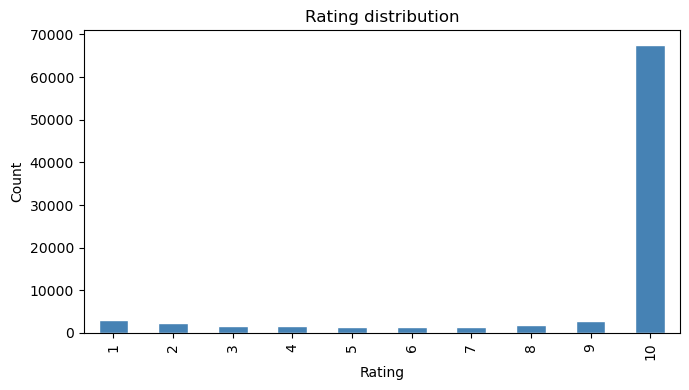

In [ ]:
#Plot 1: Rating distribution
plt.figure(figsize=(7, 4))
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Rating distribution')
plt.tight_layout()
plt.savefig('rating_dist.png')
plt.show()

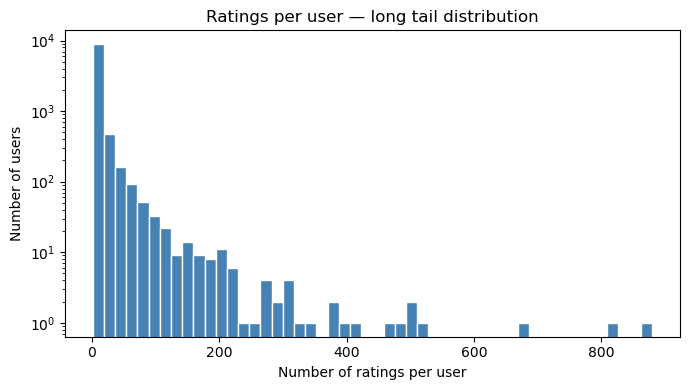

Median ratings per user: 2.0
Max ratings per user:    880


In [ ]:
# Plot 2: Ratings per user
user_counts = ratings.groupby('user_id').size()

plt.figure(figsize=(7, 4))
plt.hist(user_counts, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Number of ratings per user')
plt.ylabel('Number of users')
plt.title('Ratings per user — long tail distribution')
plt.yscale('log')
plt.tight_layout()
plt.savefig('user_activity.png')
plt.show()

print(f"Median ratings per user: {user_counts.median()}")
print(f"Max ratings per user:    {user_counts.max()}")

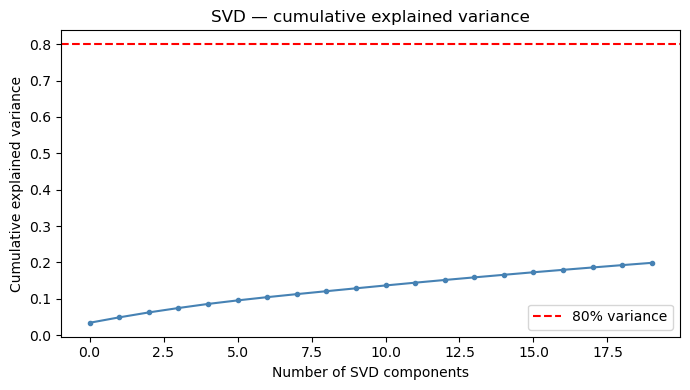

In [ ]:
#Plot 3: SVD explained variance
plt.figure(figsize=(7, 4))
plt.plot(np.cumsum(svd.explained_variance_ratio_), marker='o', markersize=3, color='steelblue')
plt.axhline(y=0.8, color='red', linestyle='--', label='80% variance')
plt.xlabel('Number of SVD components')
plt.ylabel('Cumulative explained variance')
plt.title('SVD — cumulative explained variance')
plt.legend()
plt.tight_layout()
plt.savefig('svd_variance.png')
plt.show()

Using user 30 who rated 15 items


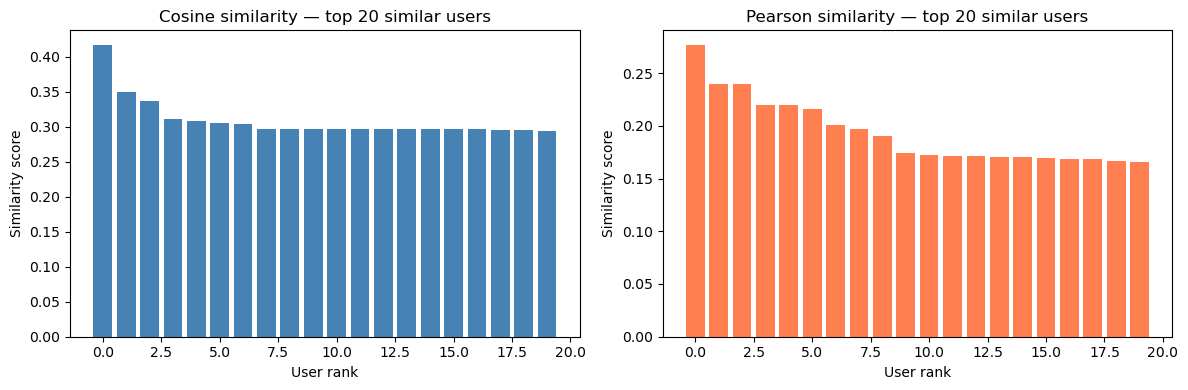

In [19]:
#Plot 4: Cosine vs Pearson similarity scores
# Find a user with moderate activity — not too many, not too few ratings
user_counts_matrix = (matrix > 0).sum(axis=1)
# Pick a user who has rated between 5 and 20 items
moderate_users = user_counts_matrix[(user_counts_matrix >= 5) & (user_counts_matrix <= 20)].index
user = moderate_users[0]

print(f"Using user {user} who rated {user_counts_matrix[user]} items")

cos_scores     = user_sim_df[user].drop(user).sort_values(ascending=False).head(20)
pearson_scores = pearson_sim_df[user].drop(user).sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(20), cos_scores.values, color='steelblue')
axes[0].set_title('Cosine similarity — top 20 similar users')
axes[0].set_xlabel('User rank')
axes[0].set_ylabel('Similarity score')

axes[1].bar(range(20), pearson_scores.values, color='coral')
axes[1].set_title('Pearson similarity — top 20 similar users')
axes[1].set_xlabel('User rank')
axes[1].set_ylabel('Similarity score')

plt.tight_layout()
plt.savefig('similarity_comparison.png')
plt.show()

In [ ]:
#Precision@K and Recall@K
THRESHOLD = 7   # rating >= 7 = user liked the item
K         = 5

precisions, recalls = [], []

sample_users = test_filtered['user_id'].unique()[:100]

for uid in sample_users:
    liked = set(
        test_filtered[
            (test_filtered['user_id'] == uid) &
            (test_filtered['rating'] >= THRESHOLD)
        ]['item_id']
    )
    if not liked:
        continue

    recs = recommend_svd(uid, n=K)
    if recs.empty:
        continue

    hits = set(recs['item_id']) & liked
    precisions.append(len(hits) / K)
    recalls.append(len(hits) / len(liked))

print(f"Precision@{K}: {np.mean(precisions):.4f}")
print(f"Recall@{K}:    {np.mean(recalls):.4f}")

Precision@5: 0.0708
Recall@5:    0.0179
